# 09 — Arquitecturas complejas y salud

Dos escenarios realistas. Primero un **pipeline multimodal** (fork y
fan-in) para ver cómo se lee una topología no trivial. Después un
**modelo complejo dentro de un nodo** al que inyectamos cuatro
patologías de entrenamiento documentadas en la literatura — y las
cazamos todas con `gradient_audit(inside=..., channels=...)` usando los
umbrales por defecto.

In [1]:
import warnings

import plotly.io as pio
import torch
import torch.nn as nn
from IPython.display import SVG

import soma
from soma import ChannelConfig, DifferentiableFilter, Filter, Graph

# Interactivo (zoom/hover/brushing) en Jupyter y VS Code, con
# fallback PNG donde no hay JS (GitHub incluido).
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].scale = 2
pio.renderers["png"].width = 950
warnings.filterwarnings("ignore", message="Full backward hook is firing")

## 9.1 — Un pipeline multimodal

Dos ramas de preprocesado (audio y texto) que convergen en una fusión,
un backbone compartido y dos cabezas. Evaluar `g` dibuja la topología.

In [2]:
class LoadAudio(Filter):
    _cache_version = "nb09-la-v1"
    def forward(self, x, state):
        return [v * 1.0 for v in x]

class Mfcc(Filter):
    _cache_version = "nb09-mfcc-v1"
    def fit(self, x, y=None):
        return {"scale": max(abs(v) for v in x) or 1.0}
    def forward(self, x, state):
        return [v / state["scale"] for v in x]

class LoadText(Filter):
    _cache_version = "nb09-lt-v1"
    def forward(self, x, state):
        return [v + 0.5 for v in x]

class Embed(Filter):
    _cache_version = "nb09-emb-v1"
    def forward(self, x, state):
        return [v * 0.1 for v in x]

class Fuse(Filter):
    _cache_version = "nb09-fuse-v1"
    def forward(self, x, state):
        # Fan-in: x = {node_id: rama}
        return [sum(vals) for vals in zip(*x.values())]

class Backbone(Filter):
    _cache_version = "nb09-bb-v1"
    def fit(self, x, y=None):
        return {"mean": sum(x) / len(x)}
    def forward(self, x, state):
        return [v - state["mean"] for v in x]

class ClfHead(Filter):
    _cache_version = "nb09-clf-v1"
    def forward(self, x, state):
        return [1.0 if v > 0 else 0.0 for v in x]

class RegHead(Filter):
    _cache_version = "nb09-reg-v1"
    def forward(self, x, state):
        return [v * 2.0 for v in x]

g = Graph.somatize(
    (LoadAudio() >> Mfcc() | LoadText() >> Embed())
    >> Fuse()
    >> Backbone()
    >> (ClfHead() | RegHead())
)
g

Graph(8 nodes, 7 edges, fitted=false)

Tras ejecutarlo bajo `track_run`, el mismo diagrama se anota con lo que
pasó: duración por nodo, hits de caché, estados.

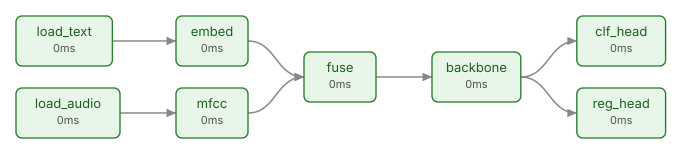

In [3]:
with g.track_run("nb09-pipeline", kind="fit", tags=["demo"]) as run:
    g.fit([3.0, -1.0, 2.0, 5.0, -4.0])

pipe_view = soma.RunView(run.dir)
SVG(pipe_view.to_svg())

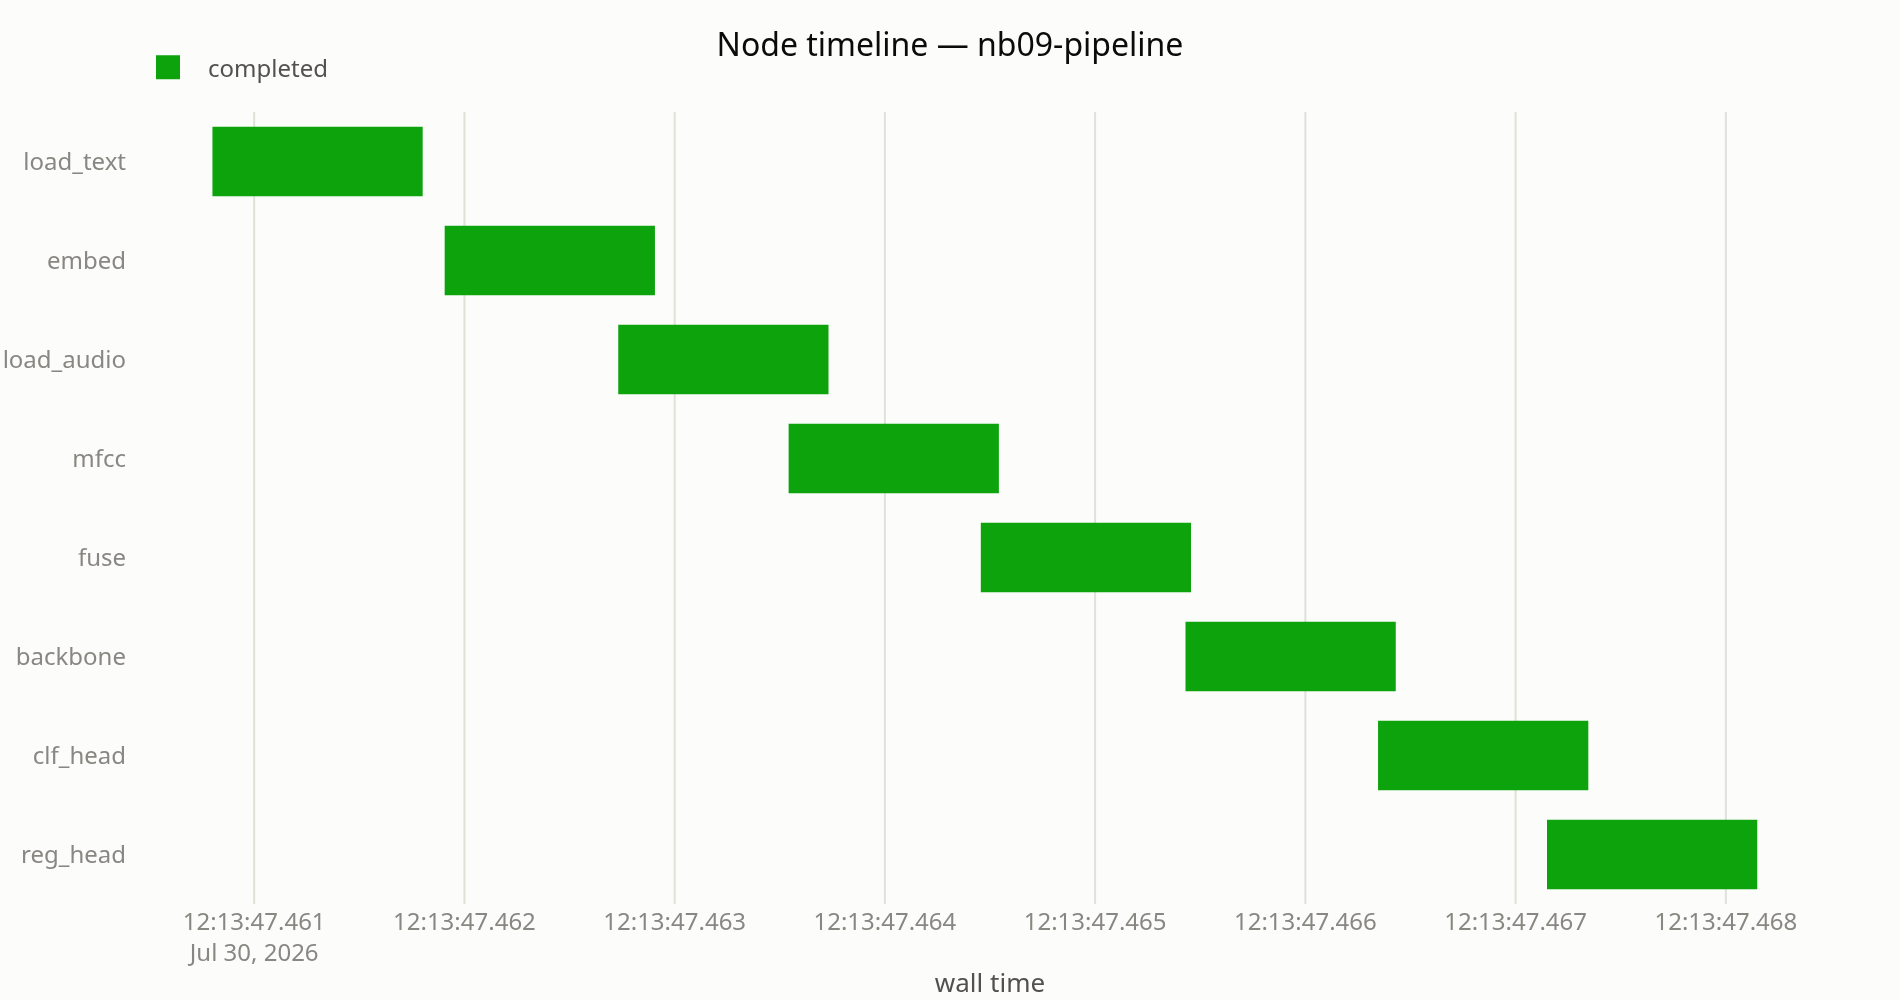

In [4]:
pipe_view.plot_gantt()

## 9.2 — Un modelo complejo dentro de un nodo, con patologías

`MultiModalEncoder` tiene ramas por modalidad, un punto de fusión
observable (`mix`), un trunk profundo y una rama de contexto. Le
inyectamos cuatro fallos clásicos:

| Patología | Cómo la inyectamos | Detector que debe saltar |
|---|---|---|
| Canales muertos (dying ReLU) | 4 bias de la capa post-fusión a −6 antes de la ReLU | `DEAD_CHANNELS(≥4)` |
| Leakage entre modalidades | las dos ramas colapsadas a los mismos pesos → codifican lo mismo | `LEAKAGE` (CKA entre grupos > 0.95) |
| Rama ignorada por el gradiente | `ctx` entra al forward multiplicada por 0 → viva en forward, sin gradiente | `IGNORED_CHANNELS(32)` + `VANISHING` |
| Vanishing en el trunk | 5 capas tanh con pesos ×0.30 | la escalera de `plot_module_flow` |

In [5]:
class MultiModalEncoder(DifferentiableFilter):
    _cache_version = "nb09-mm-v1"

    def build_module(self, input_shape):
        branches = nn.ModuleDict({
            "audio": nn.Sequential(nn.Linear(16, 16), nn.ReLU()),
            "text": nn.Sequential(nn.Linear(16, 16), nn.ReLU()),
        })
        with torch.no_grad():
            # leakage: ramas colapsadas a los mismos pesos
            branches["text"][0].weight.copy_(branches["audio"][0].weight)
            branches["text"][0].bias.copy_(branches["audio"][0].bias)
        post = nn.Sequential(nn.Linear(32, 32), nn.ReLU())
        with torch.no_grad():
            post[0].bias[-4:] = -6.0   # dying ReLU tras la fusión
        trunk = []
        for _ in range(5):
            lin = nn.Linear(32, 32)
            with torch.no_grad():
                lin.weight.mul_(0.30)   # contractivo → vanishing
            trunk += [lin, nn.Tanh()]
        return nn.ModuleDict({
            "branches": branches,
            "mix": nn.Identity(),        # observa el vector fusionado [audio|texto]
            "post": post,
            "trunk": nn.Sequential(*trunk),
            "ctx": nn.Linear(32, 32),    # se multiplicará por 0 en el forward
            "head": nn.Linear(32, 8),
        })

    def output_shape(self, input_shape):
        return (8,)

    def forward(self, x, state=None):
        import numpy as np
        x_t = x if isinstance(x, torch.Tensor) else torch.as_tensor(np.asarray(x), dtype=torch.float32)
        self.materialize(tuple(x_t.shape[1:]))
        m = self._module
        a = m["branches"]["audio"](x_t[:, :16])
        t = m["branches"]["text"](x_t[:, 16:])
        mixed = m["mix"](torch.cat([a, t], dim=1))
        deep = m["trunk"](m["post"](mixed))
        out = m["head"](deep + 0.0 * m["ctx"](mixed))
        if self.training:
            return out, {}
        return out.detach().tolist(), {}


torch.manual_seed(0)
g2 = Graph()
enc = MultiModalEncoder()
g2.node("encoder", enc)

audio = torch.randn(96, 16)
x = torch.cat([audio, audio * 0.97 + 0.05 * torch.randn(96, 16)], dim=1)
y = torch.randn(96, 8)
g2.materialize(x)
g2.train()
g2.make_optimizer(torch.optim.Adam, lr=1e-3)
enc   # el modelo se imprime como diagrama

### Auditar por dentro, con grupos de canales

`inside=` selecciona qué submódulos vigilar (patrones fnmatch) y
`ChannelConfig.groups` declara qué canales de `mix` pertenecen a cada
modalidad — la base del detector de leakage por CKA.

In [6]:
cfg = ChannelConfig(
    snapshot_every=2,
    groups={"encoder/mix": {"audio": range(0, 16), "text": range(16, 32)}},
)

with g2.track_run("nb09-health", tags=["demo"]) as run2:
    with g2.gradient_audit(
        inside={"encoder": ["branches.audio", "branches.text", "mix", "post", "ctx", "trunk.*"]},
        channels=cfg,
    ) as audit:
        for epoch in range(6):
            with g2.context() as ctx:
                g2.zero_grad()
                out, _ = g2.forward(x)
                g2.backward(ctx, nn.functional.mse_loss(out, y))
            g2.step(ctx)

for f in audit.report().filters:
    if f.flags:
        print(f"{f.filter_id:26s} {f.flags}")

encoder/mix                ['LEAKAGE']
encoder/post               ['DEAD_CHANNELS(5)']
encoder/ctx                ['VANISHING', 'IGNORED_CHANNELS(32)']


Las cuatro patologías, cazadas con los umbrales por defecto. Ahora las
mismas conclusiones, en visual:

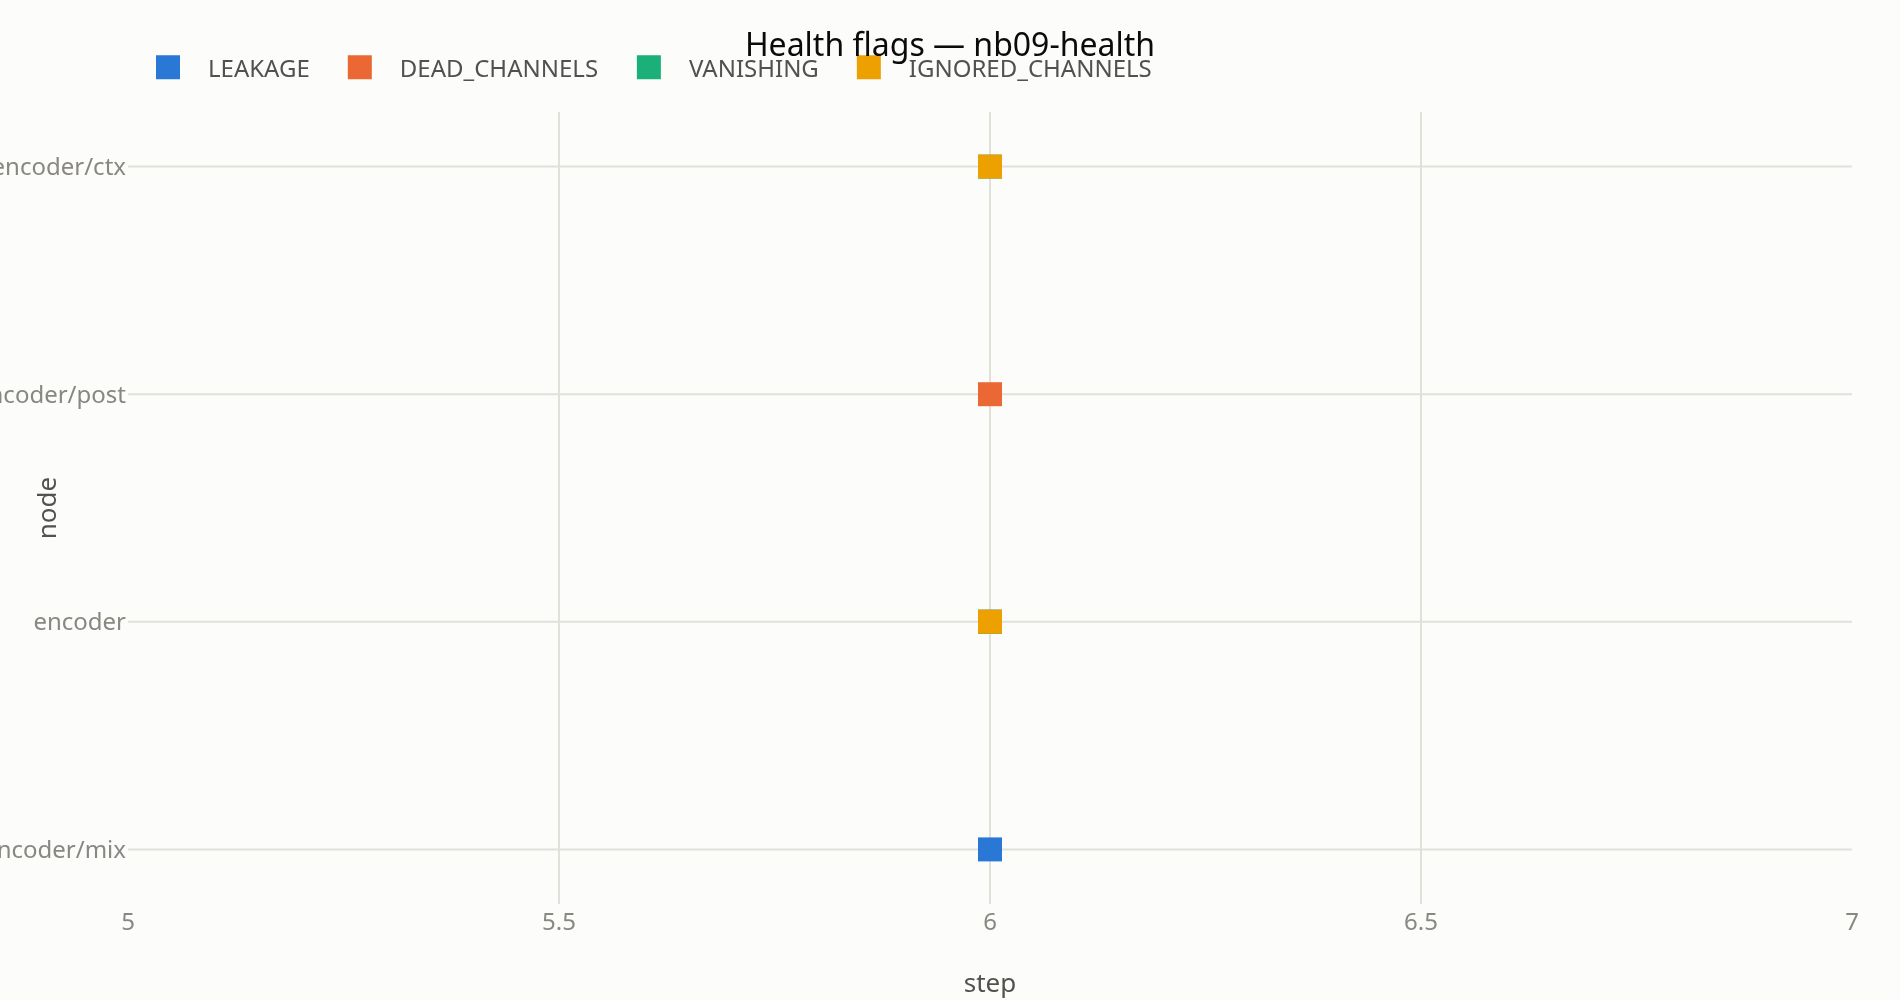

In [7]:
view = soma.RunView(run2.dir)
view.plot_health()   # qué falló, dónde y en qué step

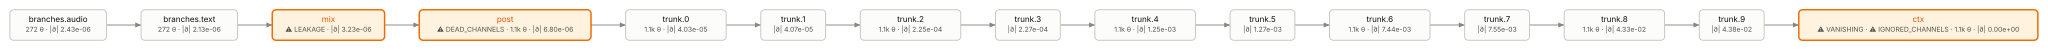

In [8]:
SVG(view.to_svg(node="encoder"))   # la arquitectura interna, capa a capa

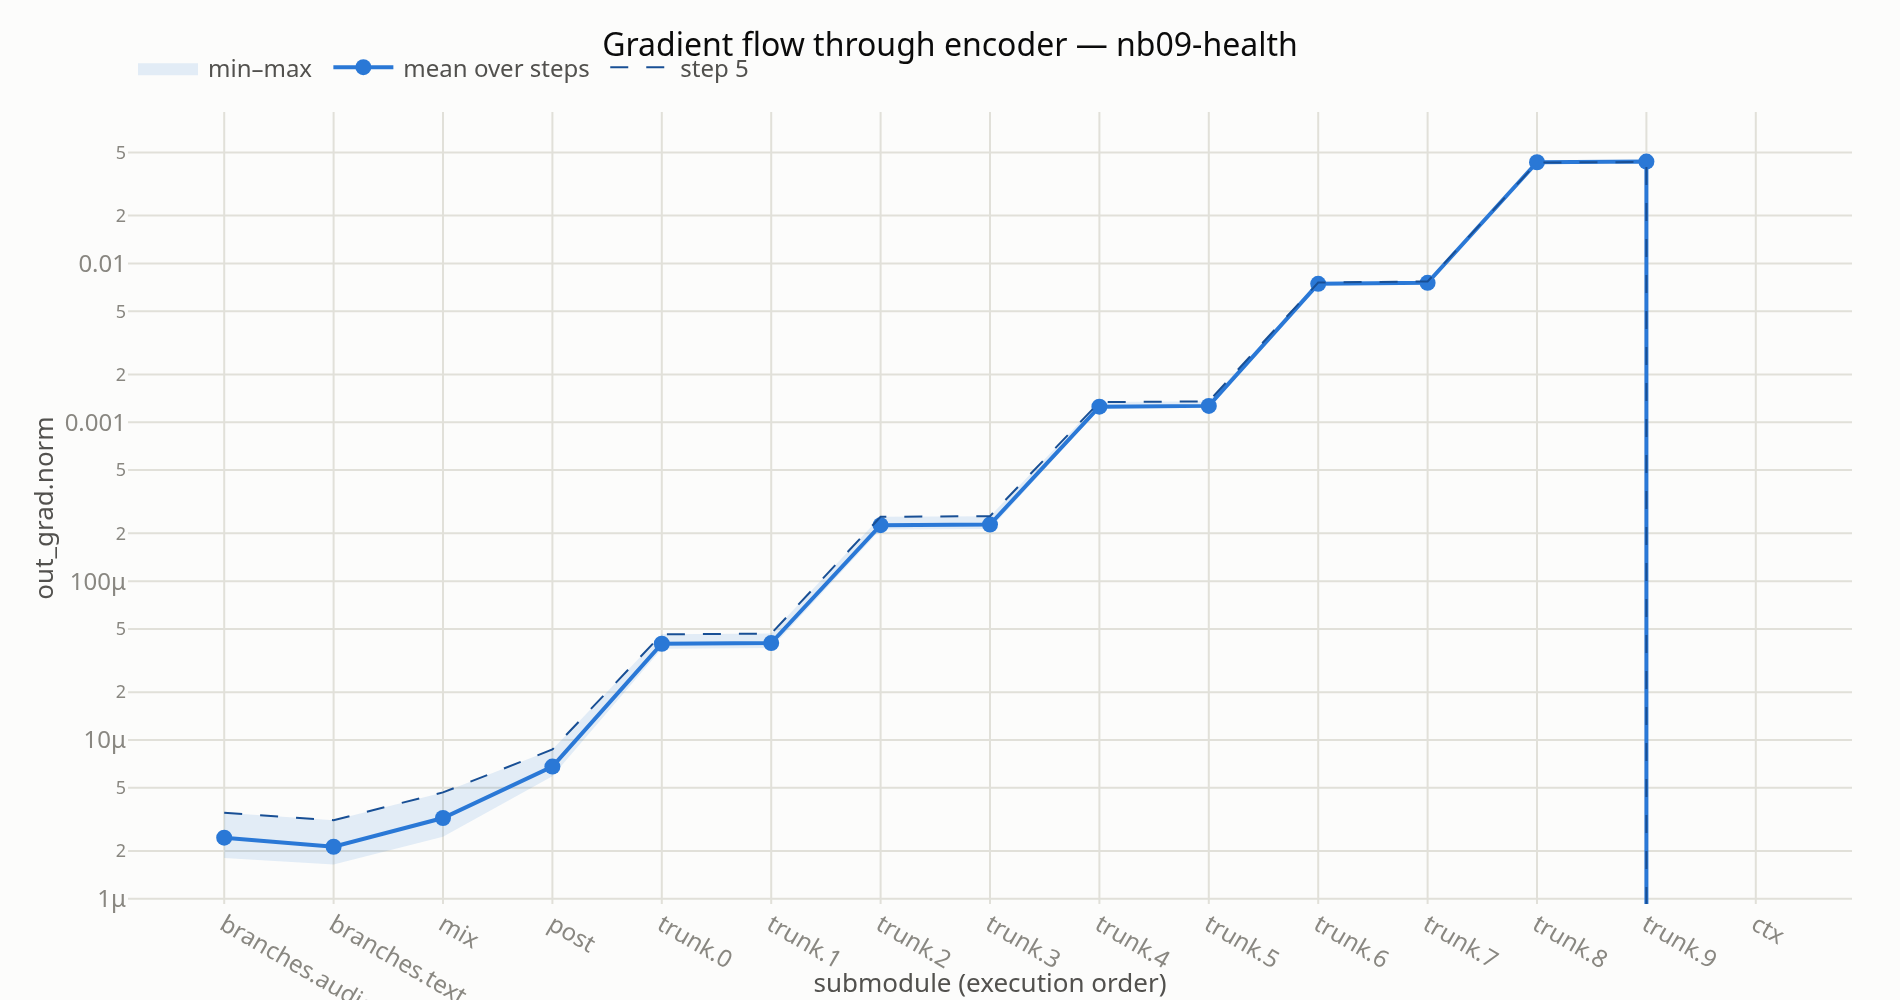

In [9]:
view.plot_module_flow("encoder")   # la escalera de vanishing del trunk

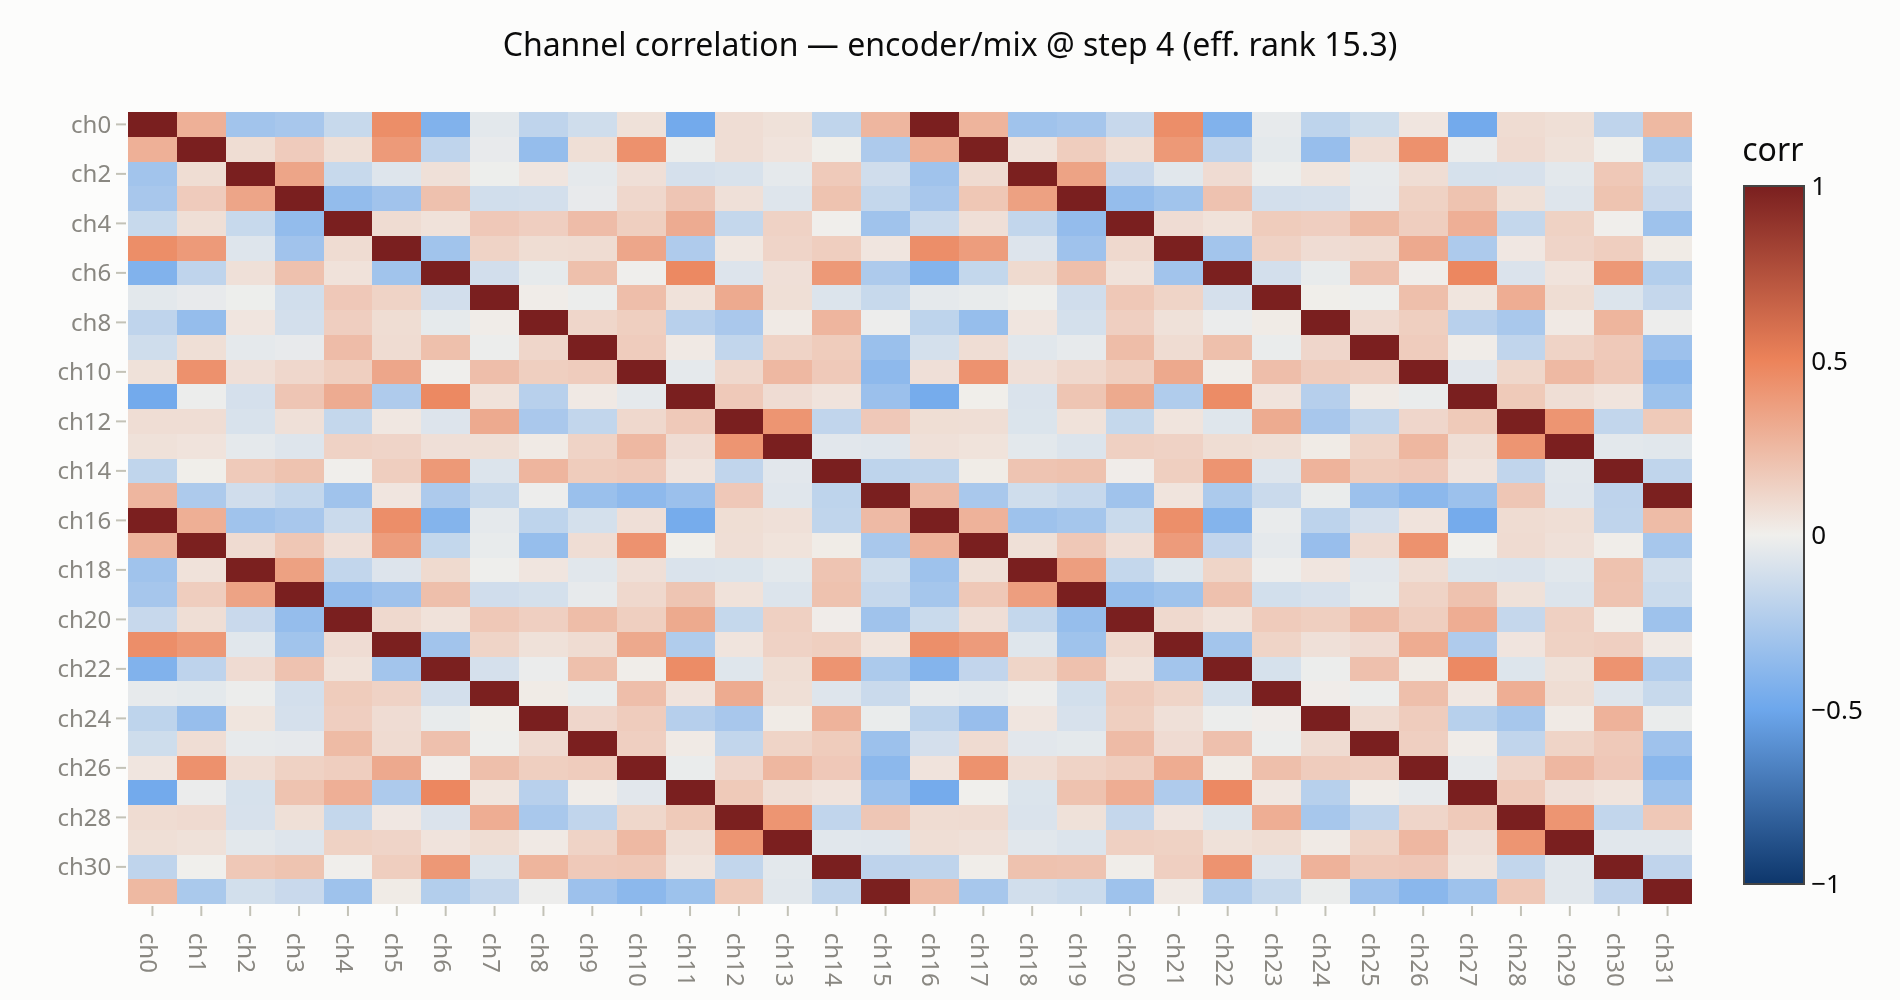

In [10]:
view.plot_channels("encoder/mix")  # audio↔texto correlacionados + 4 canales muertos (†)

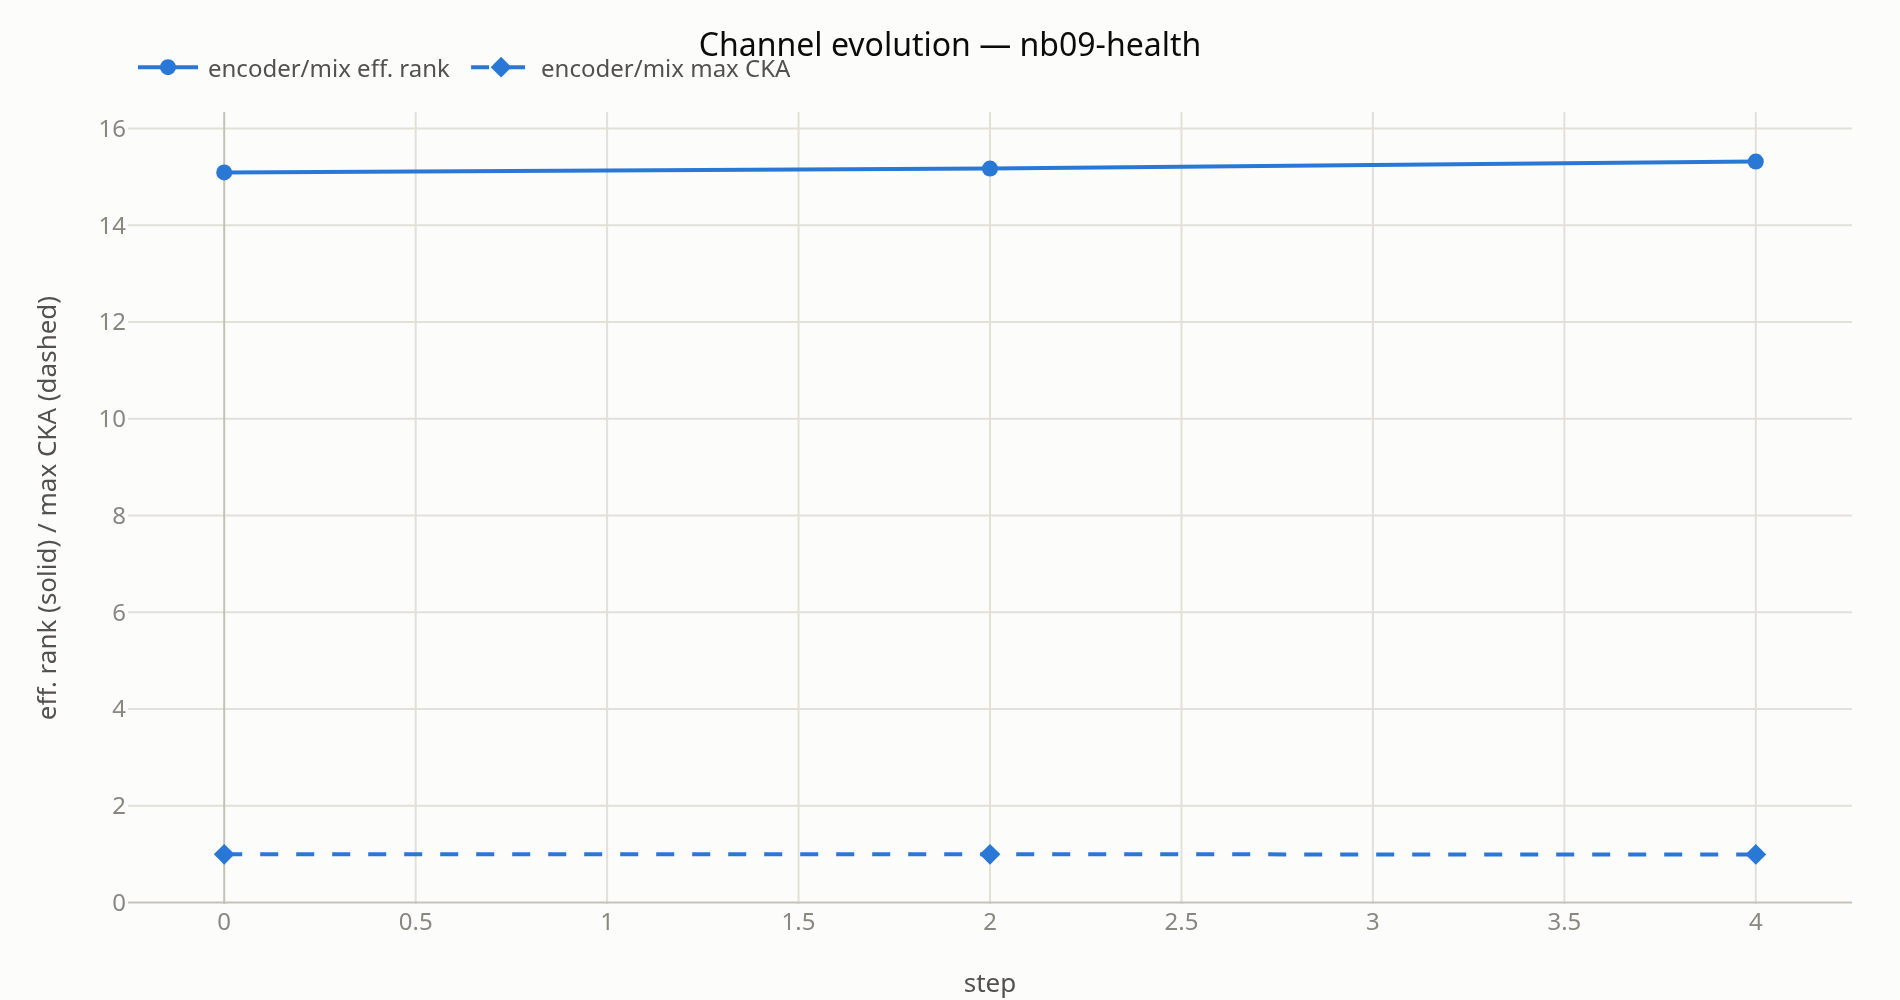

In [11]:
view.plot_channel_evolution("encoder/mix")   # rango efectivo y CKA a lo largo del training

Y en el DAG externo, el rollup marca el nodo `encoder` con el detalle
de qué submódulos fallaron — el grafo te dice *dónde mirar*, las vistas
internas te dicen *qué* pasó.

DEAD_CHANNELS      in: post
IGNORED_CHANNELS   in: ctx
LEAKAGE            in: mix
VANISHING          in: ctx


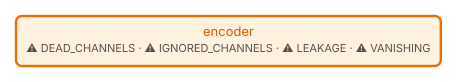

In [12]:
parent = [f for f in view.health_flags() if f["node_id"] == "encoder"]
for f in parent:
    print(f"{f['flag']:18s} {f['detail']}")
SVG(view.to_svg())

`soma report <run_id>` empaqueta todas estas vistas (sección *Module
flow* incluida) en un HTML compartible. Guía completa:
`docs → guides/gradient-audit.md`, sección *Looking inside a node*.